# 02 · Comparing the two variables together

So far we plotted pressure and temperature on separate axes. Here we put them
**together** to ask: *do they move in step?* Does the tide (pressure) leave a
fingerprint on temperature?

> 🎯 **What you'll learn in this notebook**
>
> - Plot two variables with different units on one figure (twin axes)
> - Plot them as stacked panels for long spans
> - Understand why we 'high-pass' before correlating
> - Read a scatter plot and a correlation coefficient

## The challenge: two very different scales

Pressure is hundreds-to-thousands of dbar (dominated by the instrument's depth);
temperature is a few degrees. Plotted on the same y-axis, temperature would be a
flat line at the bottom. Two solutions:

* **Twin axes** — one plot, two y-axes (left = pressure, right = temperature).
  Best for *seeing whether the wiggles align in time*.
* **Stacked panels** — two plots sharing the x-axis. Cleanest for long spans.

In [1]:
# --- Standard scientific-Python toolkit -----------------------------------
import warnings; warnings.filterwarnings("ignore")  # hide harmless library chatter
import numpy as np                 # arrays & math
import pandas as pd                # labelled time series (our main data type)
import matplotlib.pyplot as plt    # plotting
import matplotlib.dates as mdates  # nice date axes
import oceanlib as ol              # OUR helper module (sits next to this notebook)

# Make every plot a sensible default size with a light grid.
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})
pd.set_option("display.max_rows", 40)

print("Reading data from:", ol.DATA_DIR)
print("Stations available:", ol.STATIONS)

Reading data from: /Users/quakehunter/Documents/data_exploration/tidal
Stations available: ['AXBA1', 'HYSB1', 'HYS14']


In [2]:
STATION = "HYS14"          # try "AXBA1" / "HYSB1"
win = ol.DEMO[STATION]
day = pd.Timestamp(win["start"]) + pd.Timedelta(days=45)
print(STATION, "| one-day:", day.date(), "| long window:", win["start"], "→", win["end"])

HYS14 | one-day: 2018-11-16 | long window: 2018-10-02 → 2019-07-26


## One day on twin axes — does temperature follow the tide?

saved /Users/quakehunter/Documents/data_exploration/figures/02_HYS14_twin_oneday.png


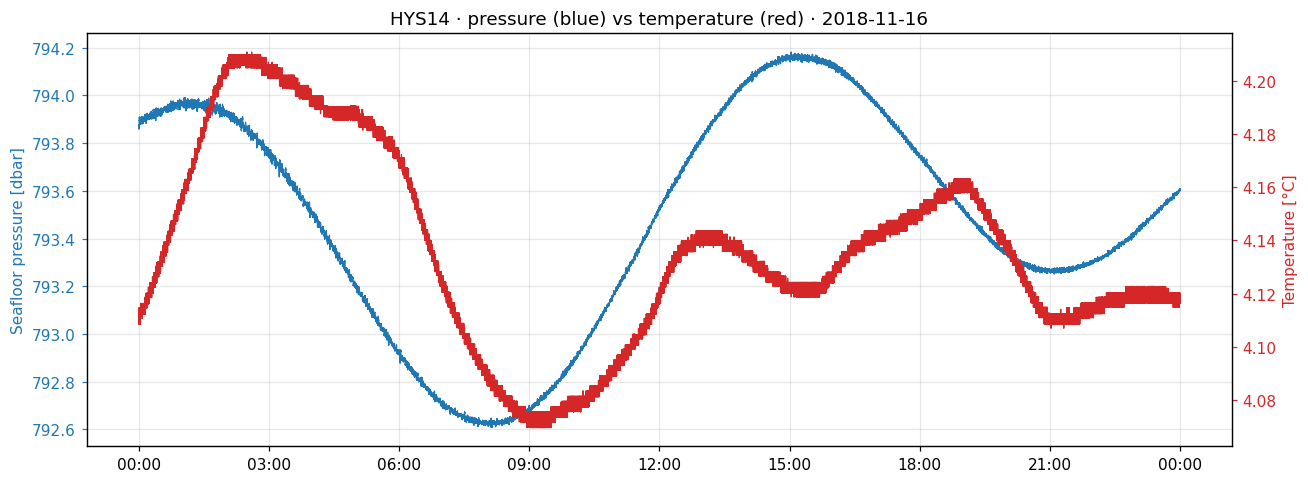

In [3]:
p = ol.load_series(STATION, "pressure", day, day)
t = ol.load_series(STATION, "temperature", day, day)

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(p.index, p.values, "C0", lw=0.8)                 # pressure on the LEFT axis
ax1.set_ylabel(ol.label_for("pressure"), color="C0"); ax1.tick_params(axis="y", colors="C0")

ax2 = ax1.twinx()                                         # a SECOND y-axis sharing the x-axis
ax2.plot(t.index, t.values, "C3", lw=0.8)                 # temperature on the RIGHT axis
ax2.set_ylabel(ol.label_for("temperature"), color="C3"); ax2.tick_params(axis="y", colors="C3")
ax2.grid(False)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.set_title(f"{STATION} · pressure (blue) vs temperature (red) · {day.date()}")
plt.tight_layout(); ol.savefig(fig, f"02_{STATION}_twin_oneday.png"); plt.show()

> 👀 **What you're seeing**
>
> Look at the *timing* of the peaks. If temperature rises and falls with the same ~12-hour rhythm as pressure, the tide is physically moving water masses of different temperature past the sensor (**tidal advection**). Often the two are offset by a few hours — a *phase lag* — which is itself interesting.

## Long term — stacked panels (hourly)

saved /Users/quakehunter/Documents/data_exploration/figures/02_HYS14_stacked_longterm.png


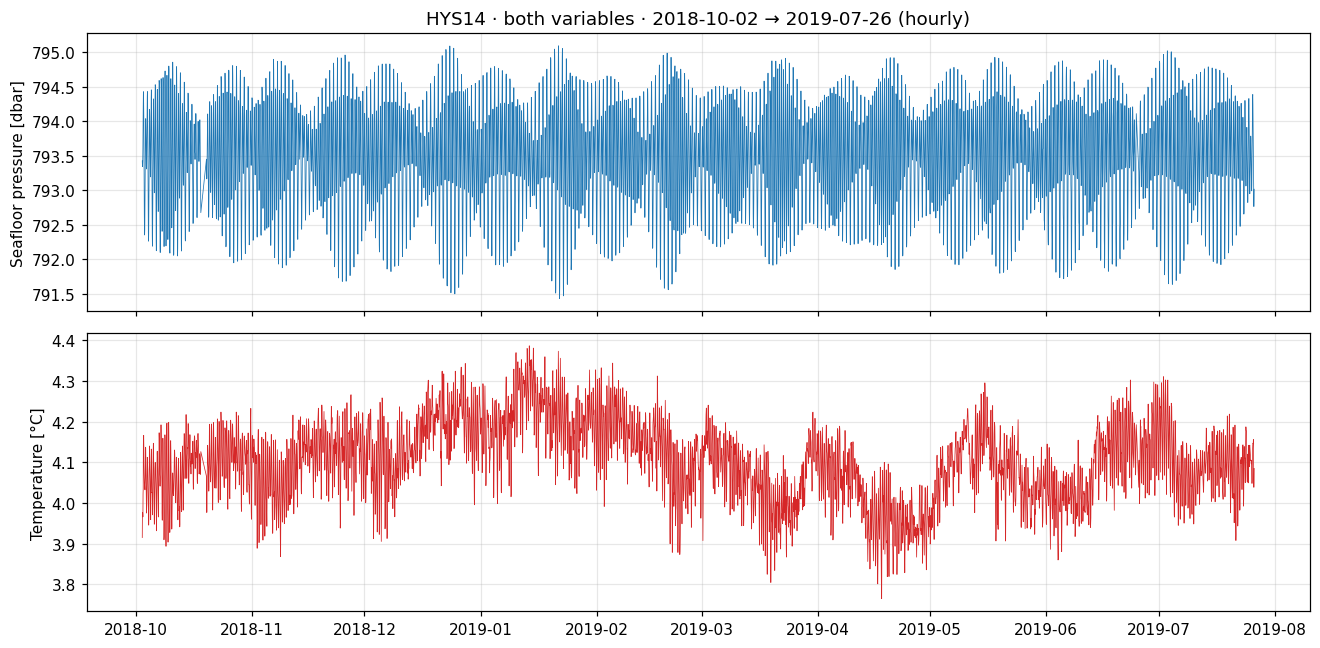

In [4]:
P = ol.load_decimated(STATION, "pressure",   win["start"], win["end"], rule="1h")
T = ol.load_decimated(STATION, "temperature", win["start"], win["end"], rule="1h")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)   # sharex = aligned time axes
axes[0].plot(P.index, P.values, "C0", lw=0.5); axes[0].set_ylabel(ol.label_for("pressure"))
axes[1].plot(T.index, T.values, "C3", lw=0.5); axes[1].set_ylabel(ol.label_for("temperature"))
axes[0].set_title(f"{STATION} · both variables · {win['start']} → {win['end']} (hourly)")
plt.tight_layout(); ol.savefig(fig, f"02_{STATION}_stacked_longterm.png"); plt.show()

> 👀 **What you're seeing**
>
> Over months, ask whether the *slow* features line up — e.g. does a seasonal warming in the bottom panel coincide with anything in pressure? Stacking with a shared x-axis makes such alignment easy to eyeball.

## Do they actually co-vary? A first statistic

"They look related" isn't proof. We can measure it with a **correlation
coefficient** `r` (−1 = perfect opposite, 0 = unrelated, +1 = perfectly
together).

But first an important step: both series have slow drift. If we correlate them
raw, the drift dominates and tells us nothing about the *fluctuations*. So we
**high-pass** — subtract a 7-day rolling average — to keep only the wiggles
faster than a week, then correlate those.

> 📖 **High-pass filter** — removing the slow part of a signal to keep the fast part. Here: value minus its 7-day running mean, leaving only changes quicker than ~a week.

Correlation r (7-day high-passed pressure vs temperature) = +0.559


saved /Users/quakehunter/Documents/data_exploration/figures/02_HYS14_scatter.png


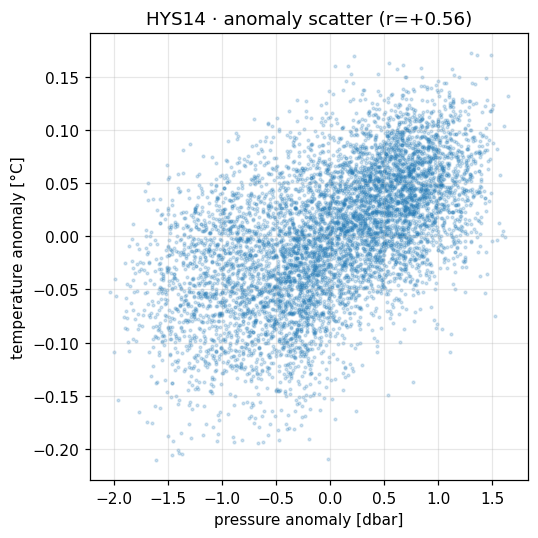

In [5]:
df = pd.concat({"pressure": P, "temperature": T}, axis=1).dropna()
# subtract a centred 7-day rolling mean from each column -> keep only fast wiggles
anom = df - df.rolling("7D", center=True, min_periods=1).mean()

r = anom["pressure"].corr(anom["temperature"])
print(f"Correlation r (7-day high-passed pressure vs temperature) = {r:+.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(anom["pressure"], anom["temperature"], s=3, alpha=0.2)
ax.set_xlabel("pressure anomaly [dbar]"); ax.set_ylabel("temperature anomaly [°C]")
ax.set_title(f"{STATION} · anomaly scatter (r={r:+.2f})")
plt.tight_layout(); ol.savefig(fig, f"02_{STATION}_scatter.png"); plt.show()

> 👀 **What you're seeing**
>
> Each dot is one hour: its pressure anomaly vs its temperature anomaly. A tilted cigar-shaped cloud means they're correlated (the sign of the tilt tells you whether high tide brings warmer or colder water). A round blob means little linear relationship. The number `r` summarises the tilt.

> ✏️ **Try it yourself**
>
> 1. Try each station. Which has the strongest pressure–temperature correlation?
> 2. Change the high-pass window from `'7D'` to `'2D'`. Does `r` change? Why might it?
> 3. On the twin-axis day plot, estimate the phase lag (hours) between pressure and temperature peaks.

> ✅ **Recap**
>
> You can display two differently-scaled variables together (twin axes & stacked panels) and quantify their relationship with a high-passed correlation and scatter plot. You met *tidal advection*, *high-pass filtering*, and the correlation coefficient `r`.
>
> ➡️ **Next:** `03_daily_plots.ipynb` — zoom into day-by-day structure.